# Demonstrating the Second-Order Sufficient Condition (SOSC)
### MECH 559 - Systems Optimization - L05
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

A focused companion to the SOSC material in this lecture: build one reusable Hessian-based classifier, then use it to sort out which of Himmelblau's nine stationary points (the same function used in the FONC notebook) are minima, which is the maximum, and which are saddles - and see exactly where the SOSC runs out of things to say.

## Learning objectives

By the end, students should be able to:

1. State the SOSC and explain what "sufficient" adds on top of the FONC's "necessary".
2. Implement a general-purpose classifier that uses the sign pattern of the Hessian's eigenvalues to label a stationary point.
3. Classify every stationary point of a multimodal function and confirm the labels visually.
4. Recognize the SOSC's blind spot: a positive- or negative-semi-definite (but not definite) Hessian is inconclusive, and the true nature of the point can only be settled by looking further.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers 3D projection)
from scipy.optimize import fsolve

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49"}

print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 1. Recap: the second-order sufficient condition

At a stationary point $\mathbf{x}^\ast$ (so $\nabla f(\mathbf{x}^\ast)=\mathbf{0}$ already holds), the second-order Taylor term controls the local shape:

$$
\Delta f \approx \tfrac12 \Delta\mathbf{x}^{\mathrm T} H^\ast \Delta\mathbf{x}.
$$

| $H^\ast$ is | then $\mathbf{x}^\ast$ is |
|---|---|
| positive definite | a (unique) local minimizer |
| negative definite | a (unique) local maximizer |
| indefinite | a saddle point |
| positive or negative **semi**-definite (not definite) | **inconclusive** - the SOSC does not decide |

Unlike the FONC, this condition is *sufficient*: if $H^\ast$ is positive definite, $\mathbf{x}^\ast$ is guaranteed to be a local minimizer, full stop. The catch is the last row of the table - semi-definiteness gives no verdict, as Section 5 shows.

---
## 2. A reusable SOSC classifier

Given $f$ and a stationary point, we estimate the Hessian by central differences and classify the point from the sign pattern of its eigenvalues. We also bring back the FONC notebook's multi-start stationary-point finder, since the SOSC only ever gets applied to points that already satisfy the FONC.

In [ ]:
def numerical_gradient(func, x, h=1e-6):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    g = np.zeros_like(x)
    for i in range(len(x)):
        step = np.zeros_like(x)
        step[i] = h
        g[i] = (func(x + step) - func(x - step)) / (2 * h)
    return g

def numerical_hessian(func, x, h=1e-4):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            si = np.zeros(n); si[i] = h
            sj = np.zeros(n); sj[j] = h
            H[i, j] = (func(x + si + sj) - func(x + si - sj) - func(x - si + sj) + func(x - si - sj)) / (4 * h**2)
    return H

def classify_stationary_point(func, x_star, tol=1e-6):
    H = numerical_hessian(func, x_star)
    eigs = np.linalg.eigvalsh(H)
    if np.all(eigs > tol):
        label = "local minimizer"
    elif np.all(eigs < -tol):
        label = "local maximizer"
    elif np.any(eigs > tol) and np.any(eigs < -tol):
        label = "saddle point"
    else:
        label = "inconclusive (Hessian only semi-definite)"
    return label, eigs, H

def find_stationary_points(func, starting_points, grad_tol=1e-6, dedupe_tol=1e-3):
    found = []
    for x0 in starting_points:
        x0 = np.atleast_1d(np.asarray(x0, dtype=float))
        x_star, info, ier, msg = fsolve(lambda x: numerical_gradient(func, x), x0, full_output=True)
        if ier != 1 or np.max(np.abs(numerical_gradient(func, x_star))) > grad_tol:
            continue
        if not any(np.linalg.norm(x_star - existing) < dedupe_tol for existing in found):
            found.append(x_star)
    return found

print("classify_stationary_point ready.")

classify_stationary_point ready.


---
## 3. Univariate example revisited

$$
f(x) = x^4 - 4x^2 + x, \qquad f''(x) = 12x^2-8
$$

We find the same three stationary points as in the FONC notebook and classify each one with $f''(x^\ast)$ (the $1\times1$ "Hessian").

x* = -1.472998   f(x*) = -5.444192   f''(x*) =  18.0367   -> local minimizer
x* =  0.126000   f(x*) =  0.062748   f''(x*) = -7.8095   -> local maximizer
x* =  1.346997   f(x*) = -2.618556   f''(x*) =  13.7728   -> local minimizer


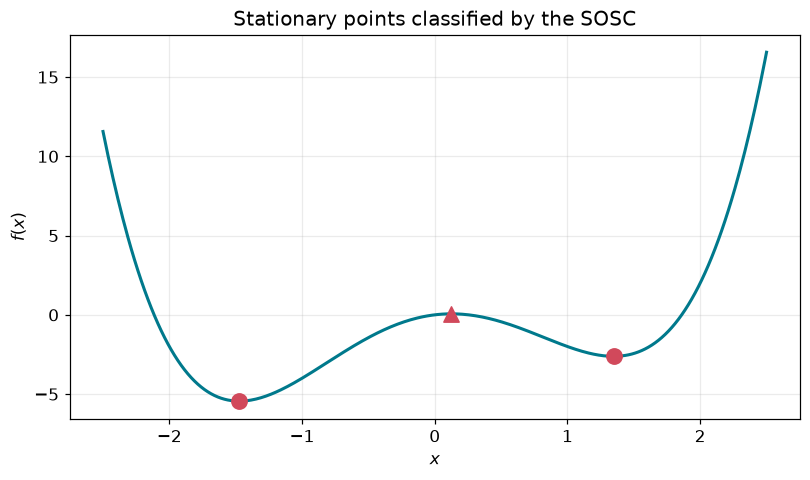

In [4]:
def f_uni(x):
    (x1,) = x
    return x1**4 - 4*x1**2 + x1

def f_uni_vec(x):
    return x**4 - 4*x**2 + x

starts_uni = [[s] for s in np.linspace(-3, 3, 13)]
stationary_uni = sorted(find_stationary_points(f_uni, starts_uni), key=lambda p: p[0])

markers = {
    "local minimizer": "o",
    "local maximizer": "^",
    "saddle point": "x",
    "inconclusive (Hessian only semi-definite)": "s",
}

xx = np.linspace(-2.5, 2.5, 400)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(xx, f_uni_vec(xx), color=COLORS["boundary"], lw=2)
for x_star in stationary_uni:
    label, eigs, H = classify_stationary_point(f_uni, x_star)
    f_val = f_uni(x_star)
    ax.scatter([x_star[0]], [f_val], color=COLORS["optimum"], marker=markers[label], s=100, zorder=3)
    print(f"x* = {x_star[0]: .6f}   f(x*) = {f_val: .6f}   f''(x*) = {eigs[0]: .4f}   -> {label}")
ax.set(xlabel="$x$", ylabel="$f(x)$", title="Stationary points classified by the SOSC")
plt.tight_layout()
plt.show()

---
## 4. Multivariate example: classifying all nine stationary points of Himmelblau's function

$$
f(x_1,x_2) = (x_1^2+x_2-11)^2 + (x_1+x_2^2-7)^2
$$

The FONC notebook found all nine stationary points of this function without telling us anything about their nature. The SOSC classifier resolves that completely: Himmelblau's function is known to have four minima (all sharing $f=0$), one local maximum, and four saddle points.

9 distinct stationary points found.

  x* = [-3.7793 -3.2832]   f(x*) =    0.0000   eig(H) = [ 70.71 133.79]   -> local minimizer
  x* = [-3.073  -0.0814]   f(x*) =  104.0152   eig(H) = [-39.65  72.44]   -> saddle point
  x* = [-2.8051  3.1313]   f(x*) =    0.0000   eig(H) = [64.84 80.55]   -> local minimizer
  x* = [-0.128  -1.9537]   f(x*) =  178.3372   eig(H) = [-50.61  20.28]   -> saddle point
  x* = [-0.2708 -0.923 ]   f(x*) =  181.6165   eig(H) = [-45.61 -16.07]   -> local maximizer
  x* = [0.0867 2.8843]   f(x*) =   67.7192   eig(H) = [-31.71  75.51]   -> saddle point
  x* = [3.3852 0.0739]   f(x*) =   13.3119   eig(H) = [-14.14  97.55]   -> saddle point
  x* = [ 3.5844 -1.8481]   f(x*) =    0.0000   eig(H) = [ 28.69 105.42]   -> local minimizer
  x* = [3. 2.]   f(x*) =    0.0000   eig(H) = [25.72 82.28]   -> local minimizer

counts: {'local minimizer': 4, 'saddle point': 4, 'local maximizer': 1}


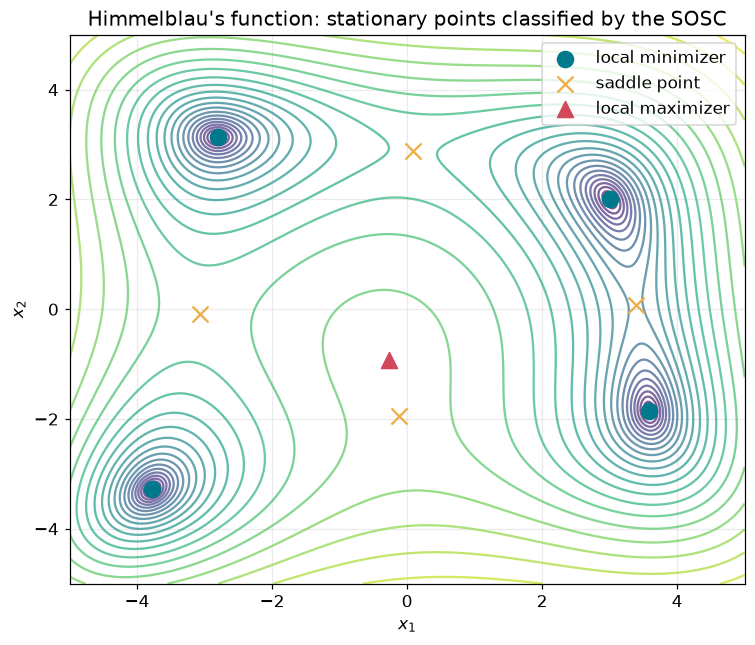

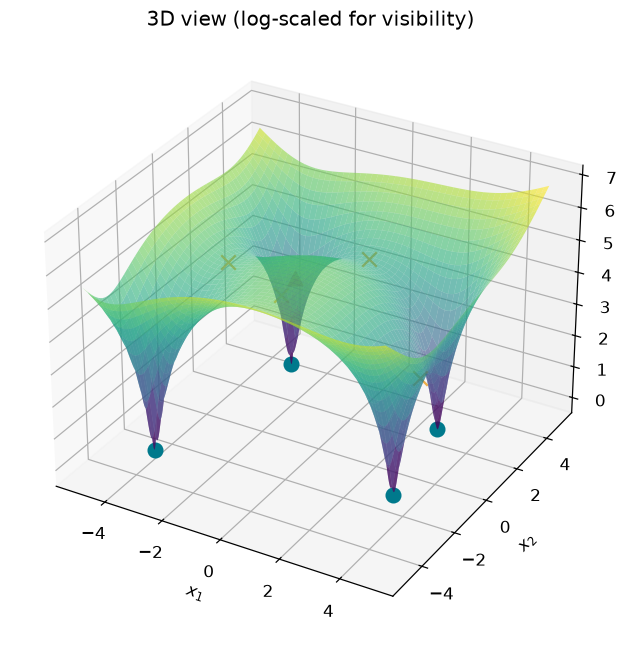

In [5]:
def himmelblau(x):
    x1, x2 = x
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

grid_1d = np.linspace(-5, 5, 7)
starts_2d = [[a, b] for a in grid_1d for b in grid_1d]
stationary_2d = find_stationary_points(himmelblau, starts_2d)
print(f"{len(stationary_2d)} distinct stationary points found.\n")

classified = []
for x_star in stationary_2d:
    label, eigs, H = classify_stationary_point(himmelblau, x_star)
    classified.append((x_star, label))
    print(f"  x* = {np.round(x_star, 4)}   f(x*) = {himmelblau(x_star):9.4f}   eig(H) = {np.round(eigs, 2)}   -> {label}")

counts = {}
for _, label in classified:
    counts[label] = counts.get(label, 0) + 1
print("\ncounts:", counts)

x1g, x2g = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
Z = (x1g**2 + x2g - 11)**2 + (x1g + x2g**2 - 7)**2

plot_style = {
    "local minimizer": ("o", COLORS["boundary"]),
    "local maximizer": ("^", COLORS["optimum"]),
    "saddle point": ("x", COLORS["accent"]),
    "inconclusive (Hessian only semi-definite)": ("s", "black"),
}

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(x1g, x2g, np.log1p(Z), levels=25, cmap="viridis", alpha=0.7)
seen_labels = set()
for x_star, label in classified:
    marker, color = plot_style[label]
    show_label = label if label not in seen_labels else None
    ax.scatter([x_star[0]], [x_star[1]], marker=marker, color=color, s=110,
               zorder=3, label=show_label)
    seen_labels.add(label)
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Himmelblau's function: stationary points classified by the SOSC")
ax.legend()
plt.tight_layout()
plt.show()

fig3d = plt.figure(figsize=(8, 6))
ax3d = fig3d.add_subplot(111, projection="3d")
ax3d.plot_surface(x1g, x2g, np.log1p(Z), cmap="viridis", alpha=0.6, linewidth=0)
for x_star, label in classified:
    marker, color = plot_style[label]
    ax3d.scatter([x_star[0]], [x_star[1]], [np.log1p(himmelblau(x_star))],
                 marker=marker, color=color, s=90)
ax3d.set(xlabel="$x_1$", ylabel="$x_2$", zlabel="log(1+f)", title="3D view (log-scaled for visibility)")
plt.tight_layout()
plt.show()

---
## 5. Where the SOSC goes silent: semi-definite Hessians

Compare three univariate functions that all satisfy $f'(0)=f''(0)=0$ - the SOSC table's last row applies to *all three*, yet they behave completely differently at $x=0$:

$$
f_1(x) = x^4 \ (\text{global min at }0), \qquad f_2(x) = x^3 \ (\text{inflection, neither min nor max}), \qquad f_3(x) = -x^4 \ (\text{global max at }0).
$$

The SOSC cannot tell these apart because it only looks at the *quadratic* term of the Taylor expansion, which vanishes identically for all three. Telling them apart requires either inspecting higher-order derivatives (the first *nonzero* one, and whether its order is even or odd) or, as here, simply looking directly at $f$ near $x=0$.

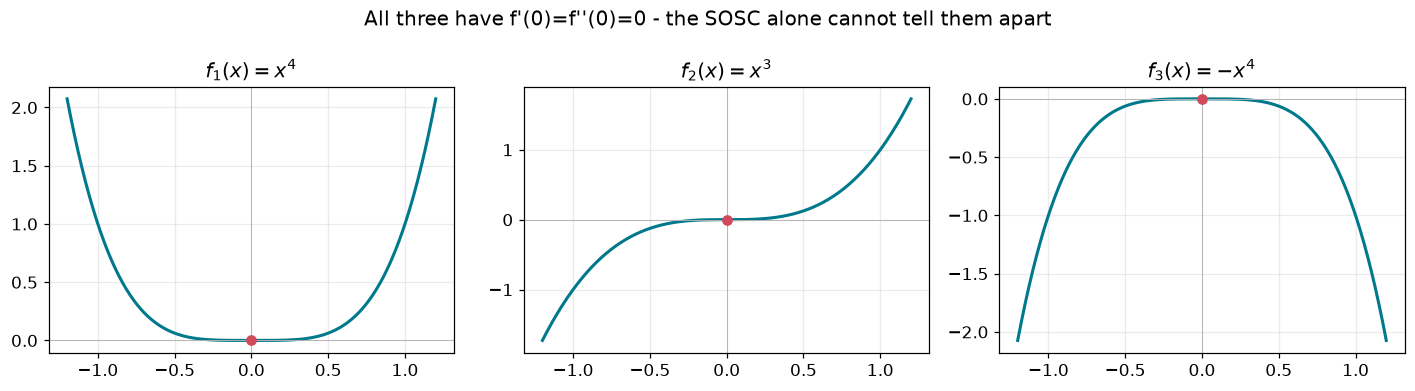

x^4 (actually a min)          : Hessian eigenvalue at 0 = 8.00e-08  ->  SOSC verdict: inconclusive (Hessian only semi-definite)
x^3 (actually an inflection)  : Hessian eigenvalue at 0 = 0.00e+00  ->  SOSC verdict: inconclusive (Hessian only semi-definite)
-x^4 (actually a max)         : Hessian eigenvalue at 0 = -8.00e-08  ->  SOSC verdict: inconclusive (Hessian only semi-definite)


In [6]:
funcs_vec = {"$f_1(x)=x^4$": lambda x: x**4, "$f_2(x)=x^3$": lambda x: x**3, "$f_3(x)=-x^4$": lambda x: -x**4}
xx = np.linspace(-1.2, 1.2, 300)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharex=True)
for ax, (name, func) in zip(axes, funcs_vec.items()):
    ax.plot(xx, func(xx), color=COLORS["boundary"], lw=2)
    ax.scatter([0], [func(np.array([0.0]))], color=COLORS["optimum"], zorder=3)
    ax.set_title(name)
    ax.axhline(0, color="0.7", lw=0.6)
    ax.axvline(0, color="0.7", lw=0.6)
plt.suptitle("All three have f'(0)=f''(0)=0 - the SOSC alone cannot tell them apart")
plt.tight_layout()
plt.show()

def f1(x):
    (x1,) = x
    return x1**4

def f2(x):
    (x1,) = x
    return x1**3

def f3(x):
    (x1,) = x
    return -x1**4

for name, func in [("x^4 (actually a min)", f1), ("x^3 (actually an inflection)", f2), ("-x^4 (actually a max)", f3)]:
    label, eigs, H = classify_stationary_point(func, [0.0])
    print(f"{name:30s}: Hessian eigenvalue at 0 = {eigs[0]:.2e}  ->  SOSC verdict: {label}")

---
## 6. Interactive: zoom in on one of Himmelblau's stationary points

Pick one of the nine classified points and inspect the local surface around it - minima and maxima look like bowls (opening up or down), while saddles curve up in one direction and down in the other.

In [7]:
def zoom_demo(index=0):
    x_star, label = classified[index]
    radius = 1.5
    xg = np.linspace(x_star[0] - radius, x_star[0] + radius, 80)
    yg = np.linspace(x_star[1] - radius, x_star[1] + radius, 80)
    Xg, Yg = np.meshgrid(xg, yg)
    Zg = (Xg**2 + Yg - 11)**2 + (Xg + Yg**2 - 7)**2
    fig = plt.figure(figsize=(9, 4))
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(Xg, Yg, Zg, cmap="coolwarm", linewidth=0, alpha=0.9)
    ax2 = fig.add_subplot(1, 2, 2)
    ax2.contour(Xg, Yg, Zg, levels=20, cmap="coolwarm")
    ax2.scatter([x_star[0]], [x_star[1]], color="black", zorder=3)
    plt.suptitle(f"Point {index}: x*={np.round(x_star, 3)}  ->  {label}")
    plt.tight_layout()
    plt.show()

if WIDGETS_AVAILABLE:
    display(widgets.interactive(zoom_demo, index=widgets.IntSlider(value=0, min=0, max=len(classified) - 1, step=1)))
else:
    print("ipywidgets is not installed; running the default case.")
    zoom_demo()

interactive(children=(IntSlider(value=0, description='index', max=8), Output()), _dom_classes=('widget-interac…

---
## Takeaways

1. The SOSC is *sufficient*: a positive (negative) definite Hessian guarantees a local min (max), full stop - no further checking needed.
2. Classifying a stationary point only requires the sign pattern of the Hessian's eigenvalues: all positive, all negative, mixed, or "it has a zero" (inconclusive).
3. On a genuinely multimodal function, the same Hessian-eigenvalue classifier that works on a simple quadratic scales up without modification - it found and correctly labeled all nine of Himmelblau's stationary points.
4. When the Hessian is only semi-definite, the SOSC has nothing to say - the true nature of the point depends on higher-order terms that the second-order Taylor expansion doesn't see.

## Optional exercises

1. Verify by hand (via the Taylor series) why $f(x)=x^4$ has a minimum at $0$ while $f(x)=x^3$ does not, even though both have $f''(0)=0$.
2. For each of Himmelblau's four minima, confirm $f(x^\ast)=0$ exactly (up to numerical tolerance). Why do all four minima share the same minimum value?
3. Modify `classify_stationary_point` to also report the *condition number* of the Hessian ($\lambda_{\max}/\lambda_{\min}$) at each point. Which of Himmelblau's minima is the most "ill-conditioned" (elongated bowl), and which is the roundest?